# Carbon Crunch — Receipt OCR Exploration

This notebook provides:
1. **Before/After preprocessing** visual comparison
2. **Sample OCR output** inspection
3. **Accuracy evaluation** table skeleton
4. **Field extraction debugging** on individual receipts

In [1]:
import sys
from pathlib import Path

# Add repo root to path
repo_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(repo_root))

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, JSON

import config

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)

## 1. Load a Sample Receipt

Loaded: /Users/minitkumar/Desktop/carbon crunch/data/raw/20.png  |  Shape: (948, 433, 3)


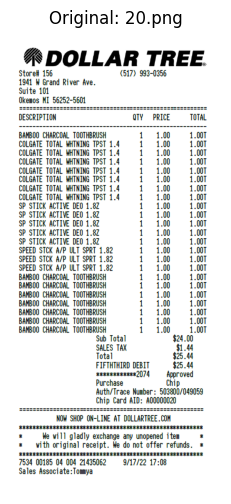

In [19]:
# Change this to any image in data/raw/
SAMPLE_IMAGE = repo_root / 'data' / 'raw'
images = sorted(
    path for path in SAMPLE_IMAGE.iterdir()
    if path.is_file() and path.suffix.lower() in {'.jpg', '.jpeg', '.png'}
)
sample_path = next((path for path in images if path.stem.lower() == '20'), None)

if sample_path is None:
    print('No data/raw/14.jpg image found.')
else:
    img = cv2.imread(str(sample_path))
    if img is None:
        raise FileNotFoundError(f'Could not read image: {sample_path}')
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print(f'Loaded: {sample_path}  |  Shape: {img.shape}')
    plt.imshow(img_rgb)
    plt.title(f'Original: {sample_path.name}')
    plt.axis('off')
    plt.show()

## 2. Before/After Preprocessing

2026-08-28 20:55:59,196 [INFO] src.preprocessing.contrast: [20] Blur score: 12843.441


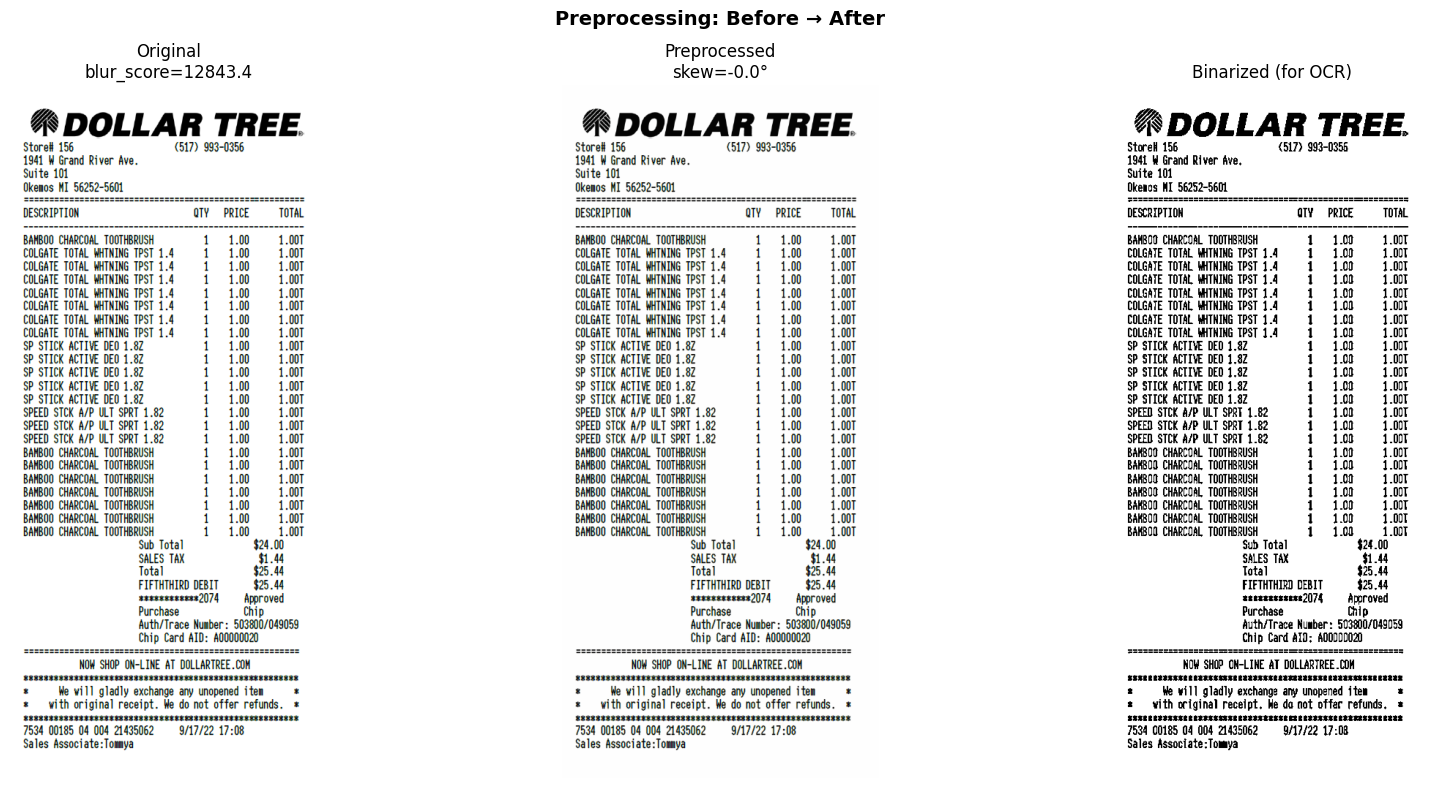

Blur score:  12843.44  (>100 = sharp)
Skew angle:  -0.00°
Extreme skew: False


In [20]:
if images:
    from src.preprocessing.contrast import preprocess_pipeline

    result = preprocess_pipeline(
        img,
        receipt_id=sample_path.stem,
        processed_dir=str(repo_root / 'data' / 'processed'),
        save_debug=True,
    )

    fig, axes = plt.subplots(1, 3, figsize=(18, 8))
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'Original\nblur_score={result["blur_score"]:.1f}')
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(result['processed'], cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'Preprocessed\nskew={result["skew_angle"]:.1f}°')
    axes[1].axis('off')

    axes[2].imshow(result['binarized'], cmap='gray')
    axes[2].set_title('Binarized (for OCR)')
    axes[2].axis('off')

    plt.suptitle('Preprocessing: Before → After', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"Blur score:  {result['blur_score']:.2f}  (>100 = sharp)")
    print(f"Skew angle:  {result['skew_angle']:.2f}°")
    print(f"Extreme skew: {result['extreme_skew']}")

## 3. OCR Output Inspection

In [21]:
if images:
    from src.ocr.engine import run_easyocr

    tokens, mean_conf = run_easyocr(
        result['processed'],
        receipt_id=sample_path.stem,
        cache_dir=str(repo_root / 'outputs' / 'ocr_raw'),
    )

    print(f'Tokens: {len(tokens)} | Mean confidence: {mean_conf:.3f}')
    print()

    token_df = pd.DataFrame([{
        'text': t['text'],
        'confidence': round(t['confidence'], 3),
        'bbox_height': round(t.get('bbox_height', 0), 1),
        'top_y': round(t['bbox'][0][1], 1),
    } for t in tokens])
    display(token_df)

2026-08-28 20:56:03,427 [INFO] src.ocr.engine: [20] Loading cached EasyOCR results from /Users/minitkumar/Desktop/carbon crunch/outputs/ocr_raw/20_easyocr.json
Tokens: 55 | Mean confidence: 0.690



,text,confidence,bbox_height,top_y
0,DOLLAR TREE,0.809,49.0,29
1,Store# 156,0.721,20.0,75
2,(517) 993-0356,0.755,20.0,75
3,1941 W Grand River Ave.,0.806,20.0,93
4,Suite 101,0.981,20.0,111
5,Okemos HI 56252-5601,0.792,20.0,129
6,DESCRIPTION,0.996,24.0,162
7,QTY,0.660,20.0,165
8,PRICE,0.998,20.0,165
9,TOTAL,0.996,20.0,165


## 4. Full Pipeline Run

In [22]:
if images:
    from src.pipeline import process_receipt

    receipt = process_receipt(str(sample_path), output_dir=str(repo_root / 'outputs'))
    display(JSON(receipt))

2026-08-28 20:56:15,162 [INFO] src.pipeline: ============================================================
2026-08-28 20:56:15,163 [INFO] src.pipeline: Processing receipt: /Users/minitkumar/Desktop/carbon crunch/data/raw/20.png
2026-08-28 20:56:15,165 [INFO] src.pipeline: ============================================================
2026-08-28 20:56:15,334 [INFO] src.preprocessing.contrast: [20] Blur score: 12843.441
2026-08-28 20:56:15,343 [INFO] src.pipeline: [20] Preprocessing done. blur=12843.44 skew=-0.00° extreme=False
2026-08-28 20:56:15,343 [INFO] src.ocr.engine: [20] Loading cached EasyOCR results from /Users/minitkumar/Desktop/carbon crunch/outputs/ocr_raw/20_easyocr.json
2026-08-28 20:56:15,344 [INFO] src.pipeline: [20] OCR engine='easyocr', tokens=55, mean_conf=0.690
2026-08-28 20:56:15,346 [INFO] src.extraction.items_prices: Extracted 3 line items.
2026-08-28 20:56:15,349 [INFO] src.structuring.schema: Receipt JSON written: /Users/minitkumar/Desktop/carbon crunch/outputs/jso

<IPython.core.display.JSON object>

## 5. Batch Processing & Accuracy Evaluation

In [6]:
# Run the full pipeline on all images in data/raw/
from src.pipeline import process_receipt
from src.summary.aggregator import generate_summary

all_receipts = []
for img_path in images:
    print(f'Processing {img_path.name}...')
    receipt = process_receipt(str(img_path), output_dir=str(repo_root / 'outputs'))
    all_receipts.append(receipt)

summary = generate_summary(all_receipts, output_dir=str(repo_root / 'outputs' / 'summary'))
print()
display(JSON(summary))

Processing 0.jpg...
2026-08-28 20:43:18,247 [INFO] src.pipeline: ============================================================
2026-08-28 20:43:18,247 [INFO] src.pipeline: Processing receipt: /Users/minitkumar/Desktop/carbon crunch/data/raw/0.jpg
2026-08-28 20:43:18,248 [INFO] src.pipeline: ============================================================
2026-08-28 20:43:18,425 [INFO] src.preprocessing.contrast: [0] Blur score: 1513.393
2026-08-28 20:43:18,437 [INFO] src.pipeline: [0] Preprocessing done. blur=1513.39 skew=-0.00° extreme=False
2026-08-28 20:43:18,437 [INFO] src.ocr.engine: [0] Loading cached EasyOCR results from /Users/minitkumar/Desktop/carbon crunch/outputs/ocr_raw/0_easyocr.json
2026-08-28 20:43:18,438 [INFO] src.pipeline: [0] OCR engine='easyocr', tokens=43, mean_conf=0.729
2026-08-28 20:43:18,438 [INFO] src.extraction.date_extractor: No date found in OCR output.
2026-08-28 20:43:18,440 [INFO] src.extraction.items_prices: Extracted 0 line items.
2026-08-28 20:43:18,442 [

KeyboardInterrupt: 

## 6. Confidence Score Distribution

In [ ]:
if all_receipts:
    rows = []
    for r in all_receipts:
        rows.append({
            'receipt_id': r['receipt_id'],
            'quality': r['quality'],
            'store_conf': r['store_name']['confidence'],
            'date_conf': r['date']['confidence'],
            'total_conf': r['total_amount']['confidence'],
            'store_flagged': r['store_name'].get('flagged', False),
            'date_flagged': r['date'].get('flagged', False),
            'total_flagged': r['total_amount'].get('flagged', False),
            'n_items': len(r['items']),
        })

    eval_df = pd.DataFrame(rows)
    display(eval_df)

    # Confidence histogram
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, col, title in zip(axes,
                               ['store_conf', 'date_conf', 'total_conf'],
                               ['Store Name Confidence', 'Date Confidence', 'Total Amount Confidence']):
        ax.hist(eval_df[col], bins=10, range=(0, 1), color='steelblue', edgecolor='white')
        ax.axvline(0.7, color='red', linestyle='--', label='Flag threshold (0.7)')
        ax.set_title(title)
        ax.set_xlabel('Confidence')
        ax.set_ylabel('Count')
        ax.legend()
    plt.tight_layout()
    plt.show()

## 7. Manual Accuracy Evaluation Table

Fill in `ground_truth` for a sample of receipts you have manually verified. 
This table provides evidence for the Extraction Accuracy rubric category.

In [ ]:
# --- Fill in ground truth for manually verified receipts ---
ground_truth = [
    # {"receipt_id": "receipt_001", "gt_store": "Walmart", "gt_date": "2024-05-12", "gt_total": "24.99"},
    # Add rows here after manually checking receipt images
]

if ground_truth and all_receipts:
    pred_map = {r['receipt_id']: r for r in all_receipts}
    eval_rows = []
    for gt in ground_truth:
        rid = gt['receipt_id']
        pred = pred_map.get(rid, {})
        eval_rows.append({
            'receipt_id': rid,
            'store_correct': pred.get('store_name', {}).get('value', '') == gt['gt_store'],
            'date_correct': pred.get('date', {}).get('value', '') == gt['gt_date'],
            'total_correct': pred.get('total_amount', {}).get('value', '') == gt['gt_total'],
        })
    acc_df = pd.DataFrame(eval_rows)
    print(acc_df)
    print(f"\nStore accuracy:  {acc_df.store_correct.mean():.1%}")
    print(f"Date accuracy:   {acc_df.date_correct.mean():.1%}")
    print(f"Total accuracy:  {acc_df.total_correct.mean():.1%}")
else:
    print('Add ground truth entries above to compute field-level accuracy.')